Датасет был взят по ссылке https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques.

В датасете есть характеристики домов, которые продаются. В характеристики входят улица, на которой расположен дом, его размеры, присутствие/отсутсвие аллеи, какой формы дом, какие услуги ЖКХ в нем есть и многое многое другое.

Цель этого датасета - суметь предугадать стоимость домов.


Основной файл с полной информацией - train.csv.

Файл test.csv то же самое, что и train, но без столба цен.
Файл data_description - вспомогательный файл, в котором прописаны расшифровки сокращений.



A) Быстрый обзор данных (Pandas)

In [17]:
import pandas as pd

df = pd.read_csv('train.csv')
print("--- Первые 5 строк ---")
print(df.head())

--- Первые 5 строк ---
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice 

In [18]:
print("--- Последние 5 строк ---")
print(df.tail())

--- Последние 5 строк ---
        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
1455         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1456         Lvl    AllPub  ...        0    NaN  MnPrv         NaN       0   
1457         Lvl    AllPub  ...        0    NaN  GdPrv        Shed    2500   
1458         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1459         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   

     MoSold YrSold  SaleType  

In [19]:
print(f"\nРазмер таблицы (строки, колонки): {df.shape}")
print("\n--- Техническая информация ---")
df.info()


Размер таблицы (строки, колонки): (1460, 81)

--- Техническая информация ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null 

In [20]:
print("--- Статистика числовых признаков ---")
print(df.describe())
print("\n--- Статистика текстовых признаков ---")
print(df.describe(include=['object', 'string']))  #используется ['object', 'string'], т.к. при обычном 'object' возникает предупреждение о возможной несовместимости в будущих версиях pandas

--- Статистика числовых признаков ---
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     2

In [21]:
print("--- Пропущенные значения в колонках ---")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0]) # Выведет только колонки с дырками

print("\n--- Типы данных по столбцам ---")
print(df.dtypes.value_counts())

duplicates = df.duplicated().sum()
print(f"\nКоличество полных дубликатов строк: {duplicates}")


--- Пропущенные значения в колонках ---
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

--- Типы данных по столбцам ---
str        43
int64      35
float64     3
Name: count, dtype: int64

Количество полных дубликатов строк: 0


😎 Пропуски и очистка

In [22]:
#Использовать dropna() в данном случае не слишком уместно, т.к. данных не сотни тысяч строк, а пропусков немалое количество. При чистке таким способо будет выкинуто слишком много данных.

#Поэтому буду использовать fillna(). Если ячейка напротив PoolQC пустая - это вполне нормально, ведь бассейна просто может и не быть. В таком случае, заполню ячейку NaN`ом.

cols_to_fix = ['PoolQC', 'MiscFeature', 'Alley', 'Fence'] #в них наибольшее кол-во пропусков
for col in cols_to_fix:
    df[col] = df[col].fillna("NaN")

electrical_mode = df['Electrical'].mode()[0]

#Если мы не знаем тип проводки, логично предположить, что там стоит самый популярный стандарт для таких домов.
df['Electrical'] = df['Electrical'].fillna(electrical_mode)

C) Расширенная статистика

In [23]:
numeric_cols = df.select_dtypes(include=['number'])
stats = numeric_cols.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

stats['mode'] = numeric_cols.mode().iloc[0]
stats['variance'] = numeric_cols.var() #Показывает, насколько сильно разбросаны цены
stats['skewness'] = numeric_cols.skew() #Показывает "гору" дешевых домов, которая плавно перейдет в спуск к дорогим домам
stats['kurtosis'] = numeric_cols.kurt() #Показывает выбросы в ценах(в данном случае - резкое подаражание на фоне дешевых домов)

stats = stats.rename(columns={'50%': 'median'})

print(stats[['min', 'max', 'mean', 'median', 'mode', 'variance', 'skewness', 'kurtosis']].head())

                min       max          mean  median    mode      variance  \
Id              1.0    1460.0    730.500000   730.5     1.0  1.777550e+05   
MSSubClass     20.0     190.0     56.897260    50.0    20.0  1.789338e+03   
LotFrontage    21.0     313.0     70.049958    69.0    60.0  5.897492e+02   
LotArea      1300.0  215245.0  10516.828082  9478.5  7200.0  9.962565e+07   
OverallQual     1.0      10.0      6.099315     6.0     5.0  1.912679e+00   

              skewness    kurtosis  
Id            0.000000   -1.200000  
MSSubClass    1.407657    1.580188  
LotFrontage   2.163569   17.452867  
LotArea      12.207688  203.243271  
OverallQual   0.216944    0.096293  


D) Фичи: Энкодинг и Инжиниринг (Feature Engineering)

In [24]:
# Применяем для колонок с малым количеством уникальных значений
df_ohe = pd.get_dummies(df, columns=['MSZoning', 'Street'], prefix='OHE')

# Позволяет сжать много категорий в фиксированное число колонок
from sklearn.feature_extraction import FeatureHasher
hasher = FeatureHasher(n_features=5, input_type='string')
hashed_features = hasher.transform(df['Neighborhood'].astype(str).apply(lambda x: [x])).toarray()
hashed_df = pd.DataFrame(hashed_features, columns=[f'neigh_hash_{i}' for i in range(5)])
df_final = pd.concat([df_ohe, hashed_df], axis=1)
#print(df_final.head())

#Общая площадь
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

#Возраст дома на момент продажи
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

E) Визуализация

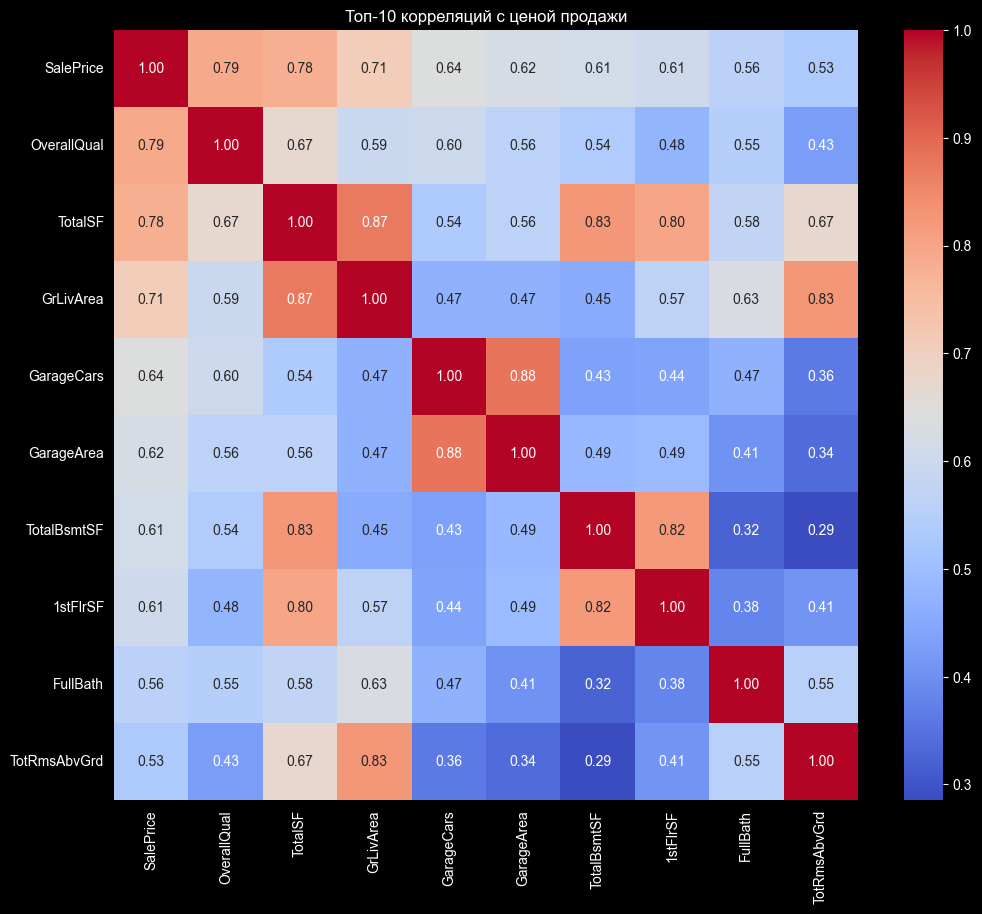

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
# Считаем корреляцию для топ-10 признаков
numeric_df = df.select_dtypes(include=['number'])
top_corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False).head(10).index
sns.heatmap(df[top_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Топ-10 корреляций с ценой продажи')
plt.show()

По хорошему, SalePrice нужно предугадвать, поэтому она не в учет.
Наибольшие изменения вносят OverallQual и TotalSF (ну, как бы почти самое важно для домов)

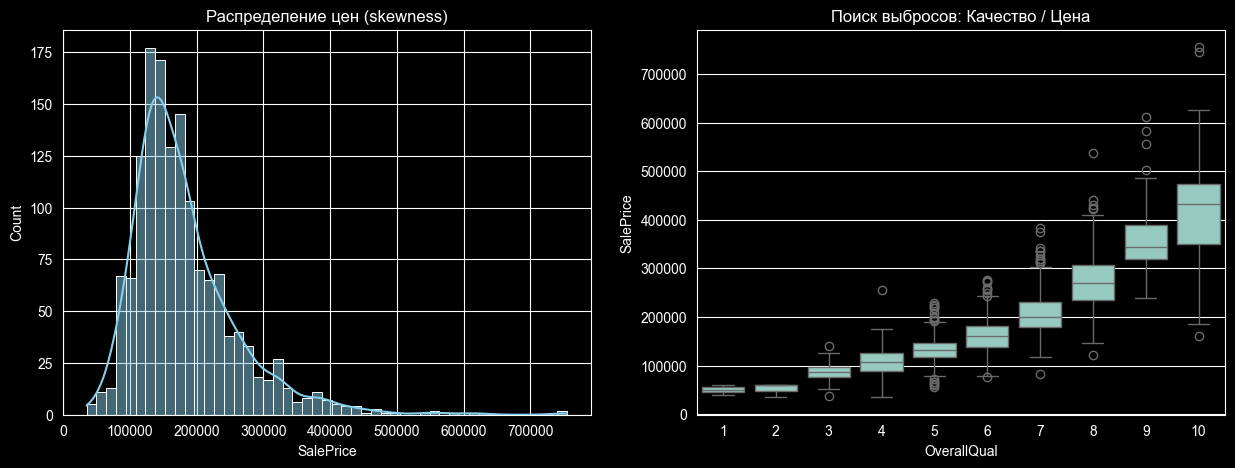

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма цен
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение цен (skewness)')

# Boxplot: Качество дома / Цена
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[1])
axes[1].set_title('Поиск выбросов: Качество / Цена')

plt.show()

In [27]:
import plotly.express as px

fig = px.scatter(df, x="GrLivArea", y="SalePrice",
                 color="OverallQual",
                 hover_data=['Neighborhood', 'YearBuilt'],
                 title="Зависимость цены от площади и района",
                 template="plotly_dark")

fig.update_layout(plot_bgcolor='black', paper_bgcolor='black')

fig.show()

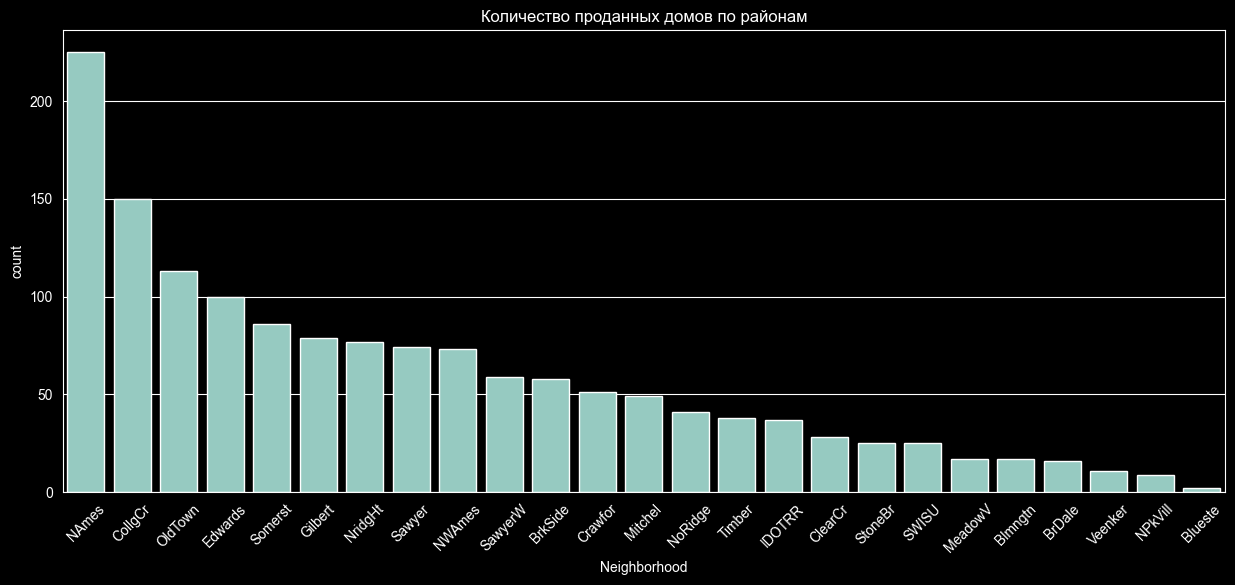

In [28]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='Neighborhood', order=df['Neighborhood'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Количество проданных домов по районам')
plt.show()

F) Итоговые выводы (Markdown)



* Что я понял:
1) В среденем домики стоят 130-200к
2) OverallQual и TotalSF - главные факторы для цены
3) Новые дома стоят явно больше, нежели старичик
4) У большого кол-ва домов нет бассейнов D:
5) Есть "элитные" райончики, где цены взлетают под 2-3 раза (например, NoRidge)
6) Тип проводки не указали только в одном поле :/
7) Ни один дом не совпал с другим полностью (для домов как бы это нормально, но все же)

* Гипотезы/наблюдения
1) Природа выбросов: На графике GrLivArea / SalePrice есть два дома с огромной площадью ( >4000 кв.), но низкой ценой. Скорее всего, дома еле стоят(в смысле чуть не разваливаются). Их стоит удалить перед обучением.
2) Качество кухни (KitchenQual) может иногда перевешивать другие хар-тики дома.
3) Возможно, цены зависят от месяца продажи (MoSold). Дома, проданные весной и в начале лета, стоят дороже.

* Что бы вы сделали дальше
Прошерстил бы список моделей и выбрал бы те, что хорошо адаптируются к примененным мною OHE и Hasher`у (например, Ridge).
Ну и если брать test.cvs как основной, то обучил бы модель предсказывать цены на дома.

* Какие подсказки брал у AI и что в итоге проверял/дописывал руками
Просил показать а как пишуться команды, которые делают, что просит условие, а потом переписывал их под те данные, которые
мог найти в таблицах.
Принцип такой: показали - повторил на своем.